# Homework 10a — Modeling: Linear Regression

**Project:** AAPL next-day volatility forecasting  
**Target:** next trading day's absolute adjusted-close return

In the lecture, we learned to fit a baseline model and diagnose assumptions with residuals. Here I adapt that workflow to my project dataset to evaluate whether an ordinary linear regression is trustworthy and useful for a portfolio risk analyst.

In [1]:
# Reproducible setup and repository discovery
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'project' / 'data' / 'processed').exists():
    ROOT = ROOT.parent
if not (ROOT / 'project' / 'data' / 'processed').exists():
    raise FileNotFoundError('Run this notebook from inside the bootcamp_zizhe_zhou repository.')

PROJECT_DIR = ROOT / 'project'
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.features import MODEL_FEATURE_COLUMNS, TARGET_COLUMN

RANDOM_SEED = 7  # Documented for reproducibility; the chronological split itself is deterministic.
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', context='notebook')
print('Repository root:', ROOT)

/Users/kevin/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/hx/wzbpnq8x7bzb6dg2sz74gg100000gn/T/matplotlib-7geqdzfx because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/kevin/Desktop/NYU/bootcamp/bootcamp_zizhe_zhou


## 1. Load and audit the project data

The input was created in Project Stage 09. Each row contains information available at the end of date *t* and a target aligned to date *t+1*. I exclude `weekday_fri` from regression so Friday is the reference category and the one-hot columns are not perfectly redundant with the intercept.

In [2]:
feature_files = sorted((PROJECT_DIR / 'data' / 'processed').glob('aapl_model_features_*.parquet'))
if len(feature_files) != 1:
    raise RuntimeError(f'Expected one model feature file, found: {feature_files}')

data_path = feature_files[0]
df = pd.read_parquet(data_path).sort_values('date').reset_index(drop=True)
feature_columns = [column for column in MODEL_FEATURE_COLUMNS if column != 'weekday_fri']

assert df['date'].is_monotonic_increasing and df['date'].is_unique
assert not df[feature_columns + [TARGET_COLUMN]].isna().any().any()
print('Data file:', data_path.relative_to(ROOT))
print('Shape:', df.shape)
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
df[['date', *feature_columns, TARGET_COLUMN]].head()

Data file: project/data/processed/aapl_model_features_20200203_20260821.parquet
Shape: (1647, 16)
Date range: 2020-02-03 to 2026-08-21


,date,return_1d,return_lag_1d,absolute_return_1d,intraday_range_pct,rolling_vol_5d,rolling_vol_21d,rolling_abs_return_5d,volume_change_1d,relative_volume_20d,weekday_mon,weekday_tue,weekday_wed,weekday_thu,target_next_day_absolute_return
0,2020-02-03,-0.002746,-0.044339,0.002746,0.037036,0.028346,0.017258,0.019551,-0.129266,1.229770,1,0,0,0,0.033014
1,2020-02-04,0.033014,-0.002746,0.033014,0.019061,0.029571,0.018360,0.020496,-0.213892,0.960537,0,1,0,0,0.008154
2,2020-02-05,0.008154,0.033014,0.008154,0.017959,0.027934,0.018363,0.017941,-0.130216,0.832546,0,0,1,0,0.011697
3,2020-02-06,0.011697,0.008154,0.011697,0.015376,0.028548,0.018346,0.019990,-0.112779,0.745614,0,0,0,1,0.013592
4,2020-02-07,-0.013592,0.011697,0.013592,0.016751,0.017455,0.018532,0.013841,0.116275,0.848032,0,0,0,0,0.004749


## 2. Chronological train/test split

A random split would train on future market regimes and evaluate on earlier observations. I therefore use the first 80% of dates for training and the final 20% for testing. No scaler is necessary for ordinary least squares predictions, and no transformation is fitted using test data.

In [3]:
split_index = int(len(df) * 0.80)
train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

X_train, y_train = train[feature_columns], train[TARGET_COLUMN]
X_test, y_test = test[feature_columns], test[TARGET_COLUMN]

assert train['date'].max() < test['date'].min()
split_summary = pd.DataFrame({
    'rows': [len(train), len(test)],
    'start': [train['date'].min().date(), test['date'].min().date()],
    'end': [train['date'].max().date(), test['date'].max().date()],
    'target_mean': [y_train.mean(), y_test.mean()],
    'target_std': [y_train.std(), y_test.std()],
}, index=['train', 'test'])
display(split_summary.round(6))

,rows,start,end,target_mean,target_std
train,1317,2020-02-03,2025-04-29,0.014379,0.014918
test,330,2025-04-30,2026-08-21,0.011185,0.011298


## 3. Fit the baseline linear regression

R² measures improvement relative to predicting the test-set mean; it can be negative out of sample. RMSE is in daily-return units, so multiplying by 100 expresses percentage points. I also compare against a deployable naive forecast equal to the training-target mean.

In [4]:
def evaluate_predictions(actual, predicted):
    return {
        'R2': r2_score(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
    }

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
test_predictions = linear_model.predict(X_test)
test_residuals = y_test.to_numpy() - test_predictions

naive_predictions = np.repeat(y_train.mean(), len(y_test))
baseline_metrics = evaluate_predictions(y_test, test_predictions)
naive_metrics = evaluate_predictions(y_test, naive_predictions)
metrics = pd.DataFrame([naive_metrics, baseline_metrics], index=['training_mean_naive', 'linear_regression'])
metrics['RMSE_percentage_points'] = metrics['RMSE'] * 100
display(metrics.round(6))
rmse_improvement = 1 - baseline_metrics['RMSE'] / naive_metrics['RMSE']
print(f'RMSE improvement versus training-mean naive forecast: {rmse_improvement:.2%}')
print(f'Negative prediction share: {(test_predictions < 0).mean():.2%}')

,R2,RMSE,RMSE_percentage_points
training_mean_naive,-0.080154,0.011725,1.172454
linear_regression,-0.021886,0.011404,1.140392


RMSE improvement versus training-mean naive forecast: 2.73%
Negative prediction share: 0.00%


In [5]:
coefficient_table = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': linear_model.coef_,
}).assign(abs_coefficient=lambda table: table['coefficient'].abs())
display(coefficient_table.sort_values('abs_coefficient', ascending=False).drop(columns='abs_coefficient').round(6))
print('Intercept:', round(float(linear_model.intercept_), 6))
print('Note: coefficient magnitudes are scale-dependent and are not feature-importance scores.')

,feature,coefficient
3,intraday_range_pct,0.293424
5,rolling_vol_21d,0.220933
6,rolling_abs_return_5d,0.170053
1,return_lag_1d,-0.069186
2,absolute_return_1d,-0.065391
0,return_1d,-0.051914
4,rolling_vol_5d,0.022905
9,weekday_mon,-0.002105
10,weekday_tue,-0.001651
12,weekday_thu,-0.001291


Intercept: 0.003085
Note: coefficient magnitudes are scale-dependent and are not feature-importance scores.


## 4. Residual diagnostics

The plots assess linearity, homoscedasticity, normality, and temporal independence. Because the target is non-negative and heavy-tailed, perfect normal residuals are not expected; the key question is whether violations are large enough to make point forecasts or uncertainty claims unreliable.

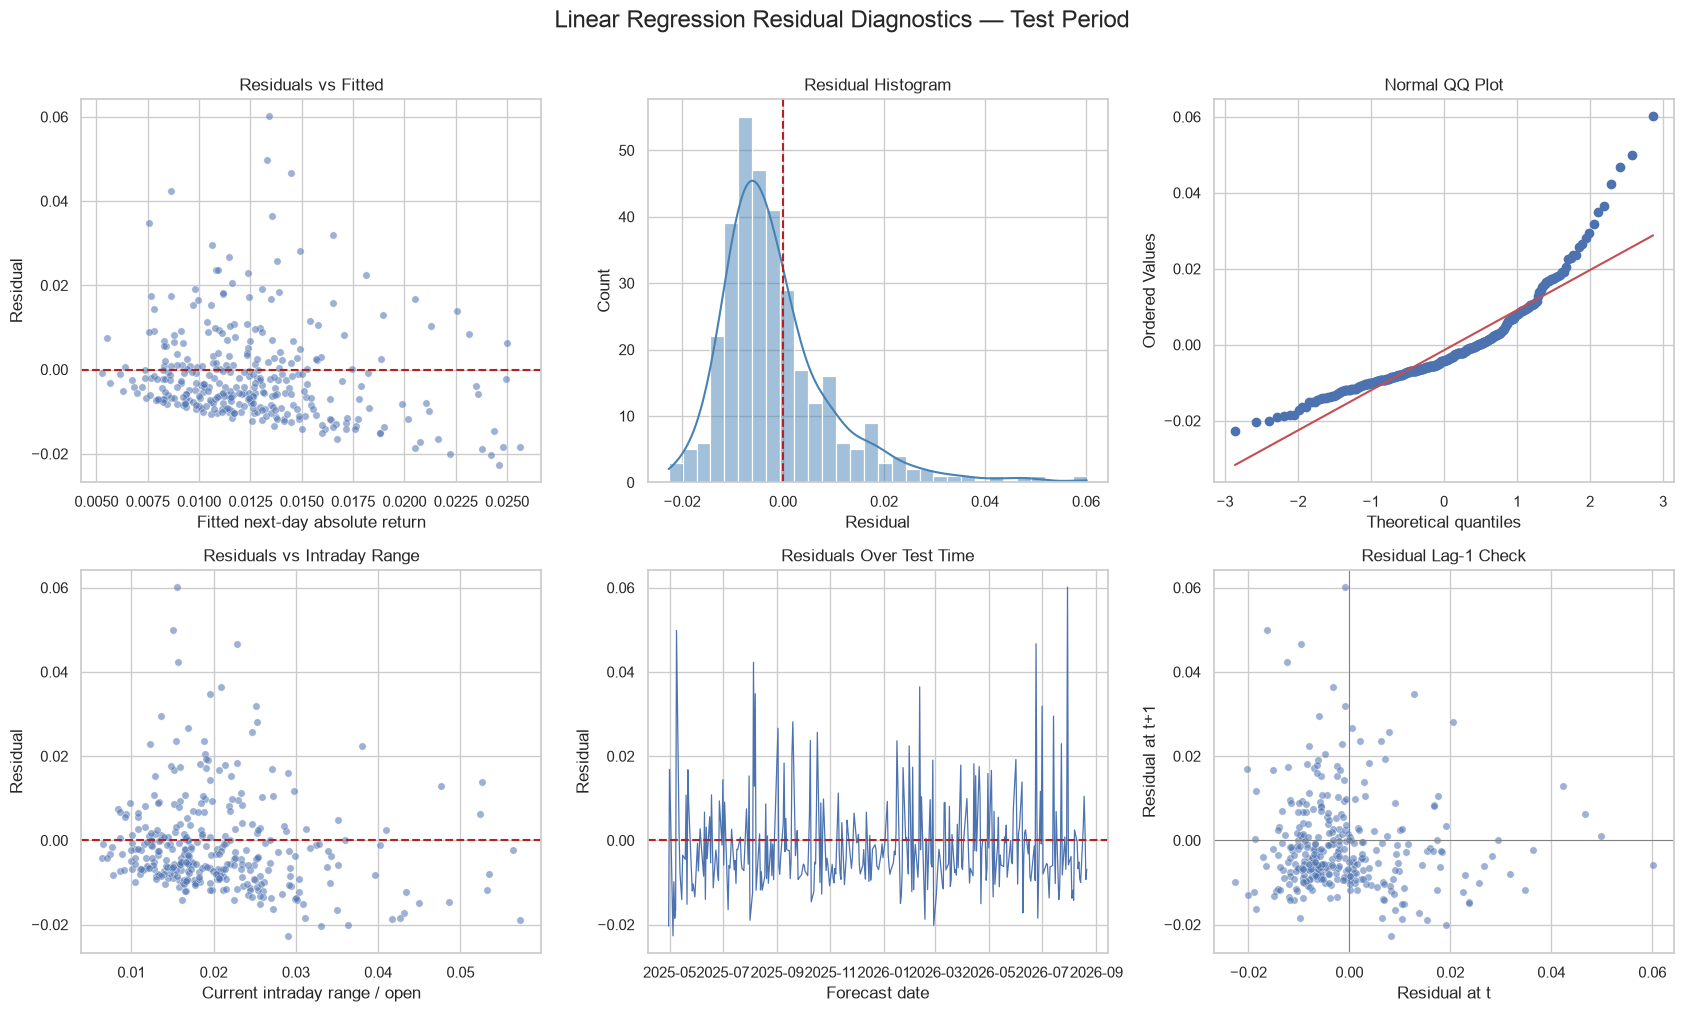

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

sns.scatterplot(x=test_predictions, y=test_residuals, alpha=0.55, s=28, ax=axes[0, 0])
axes[0, 0].axhline(0, color='firebrick', linestyle='--')
axes[0, 0].set(title='Residuals vs Fitted', xlabel='Fitted next-day absolute return', ylabel='Residual')

sns.histplot(test_residuals, bins=30, kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].axvline(0, color='firebrick', linestyle='--')
axes[0, 1].set(title='Residual Histogram', xlabel='Residual')

st.probplot(test_residuals, dist='norm', plot=axes[0, 2])
axes[0, 2].set_title('Normal QQ Plot')

sns.scatterplot(x=X_test['intraday_range_pct'], y=test_residuals, alpha=0.55, s=28, ax=axes[1, 0])
axes[1, 0].axhline(0, color='firebrick', linestyle='--')
axes[1, 0].set(title='Residuals vs Intraday Range', xlabel='Current intraday range / open', ylabel='Residual')

axes[1, 1].plot(test['date'], test_residuals, linewidth=0.9)
axes[1, 1].axhline(0, color='firebrick', linestyle='--')
axes[1, 1].set(title='Residuals Over Test Time', xlabel='Forecast date', ylabel='Residual')

sns.scatterplot(x=test_residuals[:-1], y=test_residuals[1:], alpha=0.55, s=28, ax=axes[1, 2])
axes[1, 2].axhline(0, color='gray', linewidth=0.7)
axes[1, 2].axvline(0, color='gray', linewidth=0.7)
axes[1, 2].set(title='Residual Lag-1 Check', xlabel='Residual at t', ylabel='Residual at t+1')

fig.suptitle('Linear Regression Residual Diagnostics — Test Period', fontsize=17, y=1.01)
fig.tight_layout()
plt.show()

In [7]:
lag1_correlation = pd.Series(test_residuals).autocorr(lag=1)
abs_residual_fitted_spearman = st.spearmanr(np.abs(test_residuals), test_predictions)
residual_range_spearman = st.spearmanr(test_residuals, X_test['intraday_range_pct'])
jarque_bera = st.jarque_bera(test_residuals)
diagnostic_statistics = pd.Series({
    'residual_mean': test_residuals.mean(),
    'residual_lag1_correlation': lag1_correlation,
    'spearman_abs_residual_vs_fitted': abs_residual_fitted_spearman.statistic,
    'spearman_residual_vs_intraday_range': residual_range_spearman.statistic,
    'residual_skewness': st.skew(test_residuals),
    'residual_excess_kurtosis': st.kurtosis(test_residuals),
    'jarque_bera_pvalue': jarque_bera.pvalue,
}, name='value')
display(diagnostic_statistics.to_frame().round(6))

,value
residual_mean,-0.001431
residual_lag1_correlation,-0.053683
spearman_abs_residual_vs_fitted,0.318217
spearman_residual_vs_intraday_range,-0.208469
residual_skewness,1.828670
residual_excess_kurtosis,5.124183
jarque_bera_pvalue,0.000000


### Assumption interpretation

- **Linearity:** Residuals are not fully patternless. Large positive errors remain, and residuals retain a negative association with intraday range, suggesting that one straight additive relationship does not capture the changing response or tail behavior.
- **Independence:** Lag-1 residual correlation is about −0.054, which is small and provides no obvious evidence of strong first-order dependence. This does not prove independence: overlapping rolling features, volatility regimes, and higher-order serial structure remain concerns.
- **Homoscedasticity:** The residual spread grows for larger fitted values, and the Spearman relationship between absolute residual magnitude and fitted value is positive (about 0.32). Constant error variance is therefore doubtful.
- **Normality:** The histogram and QQ plot show a long right tail. Residual skewness is about 1.83, excess kurtosis about 5.12, and the Jarque–Bera p-value is effectively zero. The normal-error assumption is strongly violated, so ordinary confidence intervals should not be trusted without robust or resampling methods.
- **Prediction versus explanation:** Coefficients describe conditional linear associations in this fitted sample, not causal effects. Correlated rolling measures also make individual coefficient interpretation unstable. Out-of-sample metrics—not coefficient signs—determine forecasting usefulness.

## 5. Stretch: add a squared range term

The baseline diagnostics suggest curvature in the relationship between today's intraday range and tomorrow's absolute return. I add `intraday_range_pct²`. This remains linear regression because the model is still a linear combination of estimated coefficients; the input basis is transformed, but no coefficient is raised to a power or multiplied by another coefficient.

In [8]:
transformed_train = train.copy()
transformed_test = test.copy()
transformed_train['intraday_range_pct_sq'] = transformed_train['intraday_range_pct'] ** 2
transformed_test['intraday_range_pct_sq'] = transformed_test['intraday_range_pct'] ** 2
transformed_features = [*feature_columns, 'intraday_range_pct_sq']

transformed_model = LinearRegression().fit(
    transformed_train[transformed_features], y_train
)
transformed_predictions = transformed_model.predict(transformed_test[transformed_features])
transformed_residuals = y_test.to_numpy() - transformed_predictions
transformed_metrics = evaluate_predictions(y_test, transformed_predictions)

comparison_metrics = pd.DataFrame(
    [naive_metrics, baseline_metrics, transformed_metrics],
    index=['training_mean_naive', 'linear_baseline', 'linear_plus_range_squared'],
)
comparison_metrics['RMSE_percentage_points'] = comparison_metrics['RMSE'] * 100
display(comparison_metrics.round(6))
print(f"Squared-term RMSE change vs baseline: {(transformed_metrics['RMSE'] / baseline_metrics['RMSE'] - 1):.2%}")
print(f'Squared-range coefficient: {transformed_model.coef_[-1]:.6f}')

,R2,RMSE,RMSE_percentage_points
training_mean_naive,-0.080154,0.011725,1.172454
linear_baseline,-0.021886,0.011404,1.140392
linear_plus_range_squared,-0.007682,0.011324,1.132438


Squared-term RMSE change vs baseline: -0.70%
Squared-range coefficient: 1.901932


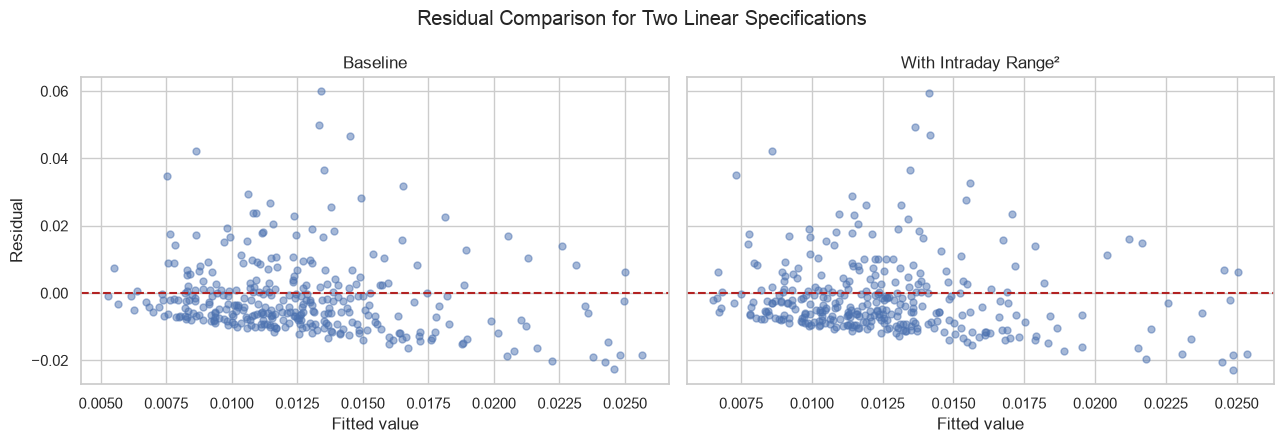

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].scatter(test_predictions, test_residuals, alpha=0.5, s=25)
axes[0].axhline(0, color='firebrick', linestyle='--')
axes[0].set(title='Baseline', xlabel='Fitted value', ylabel='Residual')
axes[1].scatter(transformed_predictions, transformed_residuals, alpha=0.5, s=25)
axes[1].axhline(0, color='firebrick', linestyle='--')
axes[1].set(title='With Intraday Range²', xlabel='Fitted value')
fig.suptitle('Residual Comparison for Two Linear Specifications')
fig.tight_layout()
plt.show()

## 6. Conclusion: do I trust this model?

I **do not trust the baseline linear regression as a standalone next-day risk forecast**. Its test R² is approximately −0.022 and RMSE is about 0.01140, or 1.14 percentage points of daily absolute return. It improves RMSE over the deployable training-mean forecast by only about 2.7%, while still performing worse than the test-period mean under the R² definition. The squared-range term produces a small improvement (R² about −0.008 and RMSE about 0.01132), but the gain is not large enough to overcome the diagnostic failures.

The main limitations are non-normal heavy-tailed residuals, increasing residual spread at higher fitted risk, specification error, correlated predictors, and possible regime shift between the training and test periods. Independence looks less problematic at lag 1, but one small autocorrelation is insufficient evidence for independent errors.

I would keep this model as a transparent benchmark, not as an approved decision model. The next steps are walk-forward evaluation, comparison with the rolling-volatility baseline, regularized/nonlinear models, target transformation or non-negative objectives, heteroskedasticity-robust uncertainty, and explicit tail-period metrics. Any model should be judged on time-ordered out-of-sample performance and its behavior during high-volatility days, not on in-sample explanatory fit or causal interpretations.